In [1]:
import os
import re
# from itertools import product
from os.path import join

# import matplotlib as mpl
import matplotlib.pyplot as plt
# import networkx as nx
import numpy as np
import pandas as pd
# import umap
# from colorspacious import cspace_converter
# from matplotlib.colors import ListedColormap
# from tqdm import tqdm

from scripts.graphics import plot_matrix, plot_graph
from scripts.statistical_analysis import estimate_all_quantiles_, acontrario_n1_all, hierarchical_olo_order

# import vpv
# from utils import plot_matrix

/Users/seginus/Documents/Repos-cloned/sueltas-typography/scripts/graphics.py:77: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  elif display_labels is 'start1':
/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

## Metadata

List of symbols: it should probably be loaded from a file (from a previous step, or from a config)

In [2]:
symbs = np.array(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z'])

Roman list of books: this gives the order for the roman adjacencies.

In [3]:
books_rm = np.array(['Fajar_0',
                  'Fajar_1',
                  'Fajar_2',
                  'Fajar_3',
                  'Lyra__0',
                  'Lyra__1',
                  'Pastr_0',
                  'Pastr_1',
                  'Sande_0',
                  'Sande_1',
                  'Aasco_0',
                  'Aigua_0',
                  'Alarc_0',
                  'Anoni_0',
                  'Anoni_1',
                  'Armes_0',
                  'Vicen_0',
                  'Avell_0',
                  'Botel_0',
                  'Bueno_0',
                  'Calde_0',
                  'Calde_1',
                  'Calde_2',
                  'Calde_3',
                  'Calde_4',
                  'Calde_5',
                  'Calde_6',
                  'Calde_7',
                  'Calde_8',
                  'Calde_9',
                  'Calle_0',
                  'Cance_0',
                  'Casti_0',
                  'Cienf_0',
                  'Corde_0',
                  'Cuell_0',
                  'Estoe_0',
                  'Gonza_0',
                  'Mesa__0',
                  'Jimen_0',
                  'Lagra_0',
                  'Leyva_0',
                  'Lope__0',
                  'Mira__0',
                  'Lope__1',
                  'Mira__1',
                  'Lope__2',
                  'Lope__3',
                  'Mira__2',
                  'Madri_0',
                  'Mira__3',
                  'Marti_0',
                  'Marti_1',
                  'Mira__4',
                  'Mira__5',
                  'Villa_0',
                  'Mira__6',
                  'Mira__7',
                  'Princ_0',
                  'Sanch_0',
                  'Mira__8',
                  'Sanz__0',
                  'Mira__9',
                  'Tirso_0',
                  'Mira__10',
                  'Ulloa_0',
                  'Mira__11',
                  'Un_in_0',
                  'Monro_0',
                  'Moral_0',
                  'Pales_0',
                  'Perez_0',
                  'Valez_0',
                  'Perez_1',
                  'Perez_2',
                  'Perez_3',
                  'Villa_1',
                  'Perez_4',
                  'Ville_0',
                  'Yoheh_0',
                  'Zabal_0',
                  'Delga_0',
                  'Perez_5',
                  'Perez_6',
                  'Perez_7',
                  'Perez_8',
                  'Perez_9',
                  'Lyra__2',
                  'Paz_Al_noble_su_sangre'])

Italics list of books: this should be the correct way to load it: from the CSV storing all the metadata of the given collection

In [4]:
df_names = pd.read_csv('tmp/corpus1.csv', sep=';', index_col=0)
books_it = df_names['Abreviation'].to_numpy()

At this point the two lists don't even match.

This step is temporary: it will be unnecessary when things are done properly ()

In [5]:
# Find books that are in both lists
idxs_rm = []
idxs_it = []
for i, b in enumerate(books_rm):
    j, = np.nonzero(books_it == b)
    if len(j) > 0:
        idxs_rm.append(i)
        idxs_it.append(j[0])
idxs_rm = np.array(idxs_rm)
idxs_it = np.array(idxs_it)

books = books_it[idxs_it]

# Verify which books have been removed
print('Books in It but not in Rm:')
for b in books_it:
    if len(np.nonzero(books_rm == b)[0]) == 0:
        print('- '+b)
print('Books in Rm but not in It:')
for b in books_rm:
    if len(np.nonzero(books_it == b)[0]) == 0:
        print('- '+b)

Books in It but not in Rm:
- Castr_0
Books in Rm but not in It:
- Paz_Al_noble_su_sangre


## Distances

Archaically called adjacencies. The variable is called `ds` for $d_s$.

The following code translates your format to mine (i.e. avalue is np.inf iff it is undefined, a diagonal value is either 0 or np.inf).

This is also a temporary step: it should not be necessary when everything is harmonized.

In [6]:
def load_adjacencies(path: str) -> np.ndarray:
    """
    Returns a float array of shape (ns, nb, nb)
    (ns = number of symbols, nb = number of books)
    representing the distance per symbol and pair of books.
    
    A value is np.inf iff it is undefined.
    A diagonal value is either 0 or np.inf.
    """
    ds = np.load(path)
    # for each character, the max value of the matrix is docs which don't have the character
    for d in ds:
        x = d.max() # Diagonal also has this value so we know it's correct
        # Find docs which have the character
        inds, = np.nonzero(np.any(d != x, axis=0))
        # Replace this max value with inf
        d[d == x] = np.inf
        # Set diagonal to 0 for docs which have the character
        d[inds, inds] = 0
    return ds

In [7]:
ds_rm = load_adjacencies('tmp/Adjacencies-corpus1-rm.npy')
ds_it = load_adjacencies('tmp/Adjacencies-corpus1-it.npy')

print(ds_rm.shape)
print(ds_it.shape)

(21, 88, 88)
(21, 89, 89)


Naturally dimensions don't match, we have to restrict to the set of books.

Temporary step

In [8]:
inds_rm = np.meshgrid(idxs_rm, idxs_rm)
inds_it = np.meshgrid(idxs_it, idxs_it)
ds_rm = ds_rm[:, *inds_rm]
ds_it = ds_it[:, *inds_it]

print(ds_rm.shape)
print(ds_it.shape)

(21, 88, 88)
(21, 88, 88)


# Compute results

Parameters. $\alpha$ and $N$ should probably go to some config file.

In [9]:
# Define alphas
alphas = np.array(sorted([0.1*2**i for i in range(-5, 3)]+[0.15*2**i for i in range(-5, 3)]))
print(alphas)

# Define epsilon and N
epsilon = 0.01
Nbooks = len(books)
N = Nbooks*(Nbooks-1)//2


[0.003125  0.0046875 0.00625   0.009375  0.0125    0.01875   0.025
 0.0375    0.05      0.075     0.1       0.15      0.2       0.3
 0.4       0.6      ]


Let's go

In [10]:
qs_it = estimate_all_quantiles_(ds_it, alphas=alphas, inds_train=None)
qs_rm = estimate_all_quantiles_(ds_rm, alphas=alphas, inds_train=None)

n_rm, n1_rm, _ = acontrario_n1_all(ds_rm, qs_rm, alphas=alphas, N=N, epsilon=epsilon)
n_it, n1_it, _ = acontrario_n1_all(ds_it, qs_it, alphas=alphas, N=N, epsilon=epsilon)

n1max_rm = n1_rm.max(axis=0)
n1max_it = n1_it.max(axis=0)

## To produce the list of candidate symbols
#
# from scripts.statistical_analysis import final_outputs
#
# n_rm, n1_rm, c_rm = acontrario_n1_all(ds_rm, qs_rm, alphas=alphas, N=N, epsilon=epsilon)
# n1max_rm, cands_rm = final_outputs(n1_rm, c_rm)

/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


# Produce figures

In [11]:
save_root = 'figs-icdar'
os.makedirs(save_root, exist_ok=True)

## Weights, order

In [17]:
w_rm = n1max_rm/n_rm
w_it = n1max_it/n_it

idxs_order = hierarchical_olo_order(1-(w_rm+w_it)/2)
inds_order = np.meshgrid(idxs_order, idxs_order)

# This line is important, do not mess it up!!!
df = df_names.copy().loc[idxs_it].iloc[idxs_order]

Optional: print table of books in the computed order

In [13]:
def esc_spa(s: str):
    s = s.replace('á', '{\\\'a}')
    s = s.replace('é', '{\\\'e}')
    s = s.replace('í', '{\\\'i}')
    s = s.replace('ó', '{\\\'o}')
    s = s.replace('ú', '{\\\'u}')
    s = s.replace('Á', '{\\\'A}')
    s = s.replace('É', '{\\\'E}')
    s = s.replace('Í', '{\\\'I}')
    s = s.replace('Ó', '{\\\'O}')
    s = s.replace('Ú', '{\\\'U}')
    s = s.replace('ñ', '{\\~n}')
    s = s.replace('Ñ', '{\\~N}')
    return s

def sanitize_signatura(sig: str) -> str:
    if len(sig) == 0:
        return sig
    # remove spaces, unless they are a separator
    sig = re.sub(r'(?<=[a-zA-Z0-9]) +(?=[a-zA-Z0-9])', '/', sig)
    sig = sig.replace(' ', '')
    # handle parentheses: replace by "-", unless it separates nothing
    sig = re.sub(r'\)(?=.)|(?<=.)\(', '/', sig)
    sig = re.sub(r'\)(?!.)|(?<!.)\(', '', sig)
    # forbidden and "-" → "-"
    sig = re.sub(r'[<>:"/\\|?*._-]+', '/', sig)
    return sig

In [14]:
# tab = ' '*8
# print(tab+'\\toprule')
# print(tab+'Index & Signature & Printer & Title \\\\')
# print(tab+'\\midrule')
# for i, row in enumerate(df.itertuples()):
#     printer = '---' if pd.isna(row.Printer) else row.Printer.split(' ')[-1]
#     sig = row.Signature.replace('-', '/')
#     print(f'{tab}{i} & {row.Library}, {sig} & {esc_spa(printer)} '
#          +f'& {esc_spa(row.Title)} \\\\')
# print(tab+'\\bottomrule')

display(df)

,Document,Abreviation,Library,Signature,Title,Printer,Remarks
29,LagrancomediaAmorconvalorseobliga,Lagra_0,BNE,T-55307-1,Amor con valor se obliga,NaN,NaN
48,Mira de Amescua_LahijadeCarlosQuintoComediafamosa,Mira__9,BNE,T-55274-5,La hija de Carlos V,NaN,NaN
26,Estoeshechocomediafamosa,Estoe_0,BNE,T-55329-22,Acertar pensando errar,NaN,NaN
77,Perez de Montalban_Elzelosoestremeocomediafamo...,Perez_9,BNE,T-55281-7,El celoso extremeño,NaN,NaN
76,Perez de Montalban_Elexamendemaridoscomediafam...,Perez_8,BNE,T-55281-13,Antes que te cases mira lo que haces y examen ...,NaN,NaN
...,...,...,...,...,...,...,...
67,Vicente_El amante mas honesto,Vicen_0,BNE,T-55317-30,El bandido más honrado y que tuvo mejor fin,NaN,NaN
3,Anonima_Lo que pasa en un torno de monjas,Anoni_0,BNE,T-55294-3,Lo que pasa en un torno de monjas,NaN,NaN
11,Calderon_Amado,Calde_2,BNE,T-55345-22,Amado y aborrecido,NaN,NaN
55,Perez de Montalban_Elrigorenlainocenciacomedia...,Perez_1,BNE,T-55281-6,El rigor en la inocencia,NaN,NaN


## Highlighting

In [15]:
printers = ['Bedmar', 'Fajardo', 'Lyra', 'Pastrana', 'Sande', 'X']
colors = plt.cm.tab10.colors[:len(printers)]

hid = df['Remarks'] == 'hidden'
new = df['Remarks'] == 'new'

## Matrix

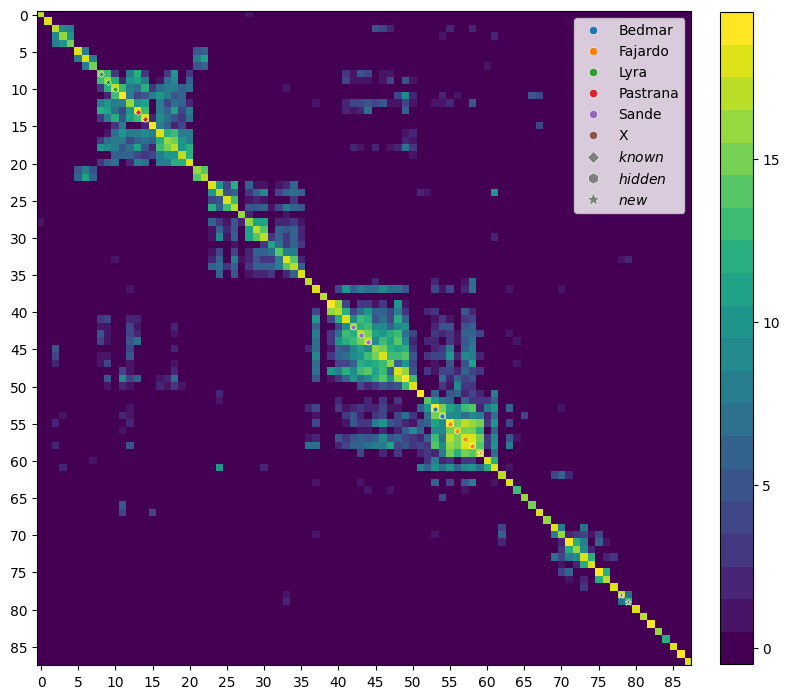

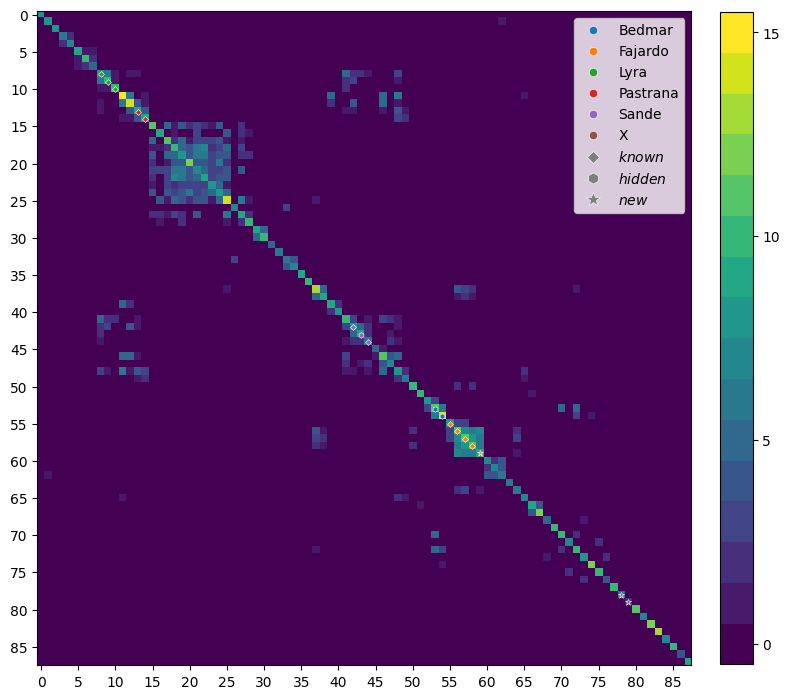

In [16]:
style = dict(mec='white', mew=0.4)

for n1max, sfx in zip([n1max_rm, n1max_it], ['rm', 'it']):
    plot_matrix(n1max[inds_order],
                display_labels=None, include_values=False, xticks_rotation='horizontal',
                figsize=(8, 8))

    # Plot the diagonal markers
    for color, printer in zip(colors, printers):
        # Find books attributed to the printer
        yes = ~df['Printer'].isna() & df['Printer'].str.endswith(printer)
        # those which are currently known
        idxs, = np.nonzero(yes & ~hid & ~new)
        plt.plot(idxs, idxs, 'D', markersize=3.0, color=color, **style)
        # those which are known but hidden
        idxs, = np.nonzero(yes & hid)
        plt.plot(idxs, idxs, 'h', markersize=4.0, color=color, **style)
        # those which are new: attribution from our work
        idxs, = np.nonzero(yes & new)
        plt.plot(idxs, idxs, '*', markersize=5.0, color=color, **style)
        # Plot 
        plt.plot([], [], 'o', color=color, label=printer,  **style)

    # Empty plot to complete the legend
    plt.plot([], [], 'D', color='tab:gray', label=r'$\mathit{known}$', markersize=6, **style)
    plt.plot([], [], 'h', color='tab:gray', label=r'$\mathit{hidden}$', markersize=8, **style)
    plt.plot([], [], '*', color='tab:gray', label=r'$\mathit{new}$', markersize=10, **style)

    plt.legend()
    plt.tight_layout()

    plt.savefig(join(save_root, f'n1hat1{sfx}.svg'), bbox_inches='tight', pad_inches=0, dpi=800)

## Graph

In [18]:
scale = 1

# Prepare the marker for each vertex of the graph

markers_vx = np.full(len(books), 's')
markersizes_vx = np.full(len(books), scale*10.0)
colors_vx = np.zeros((len(books), 3))

for color, printer in zip(colors, printers):
    yes = ~df['Printer'].isna() & df['Printer'].str.endswith(printer)
    idxs, = np.nonzero(yes)
    colors_vx[idxs] = color
    #
    idxs, = np.nonzero(yes & ~hid & ~new)
    markers_vx[idxs] = 'D'
    markersizes_vx[idxs] = scale*30.0
    #
    idxs, = np.nonzero(yes & hid)
    markers_vx[idxs] = 'h'
    markersizes_vx[idxs] = scale*40.0
    #
    idxs, = np.nonzero(yes & new)
    markers_vx[idxs] = '*'
    markersizes_vx[idxs] = scale*50.0

/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/seginus/Documents/Repos-cloned/sueltas-typography/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


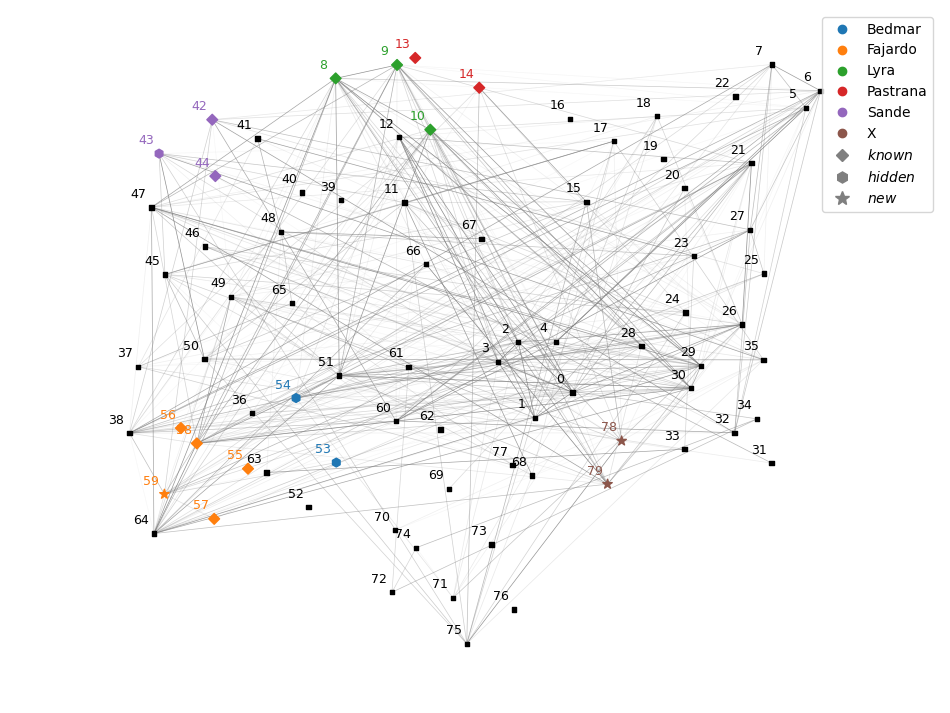

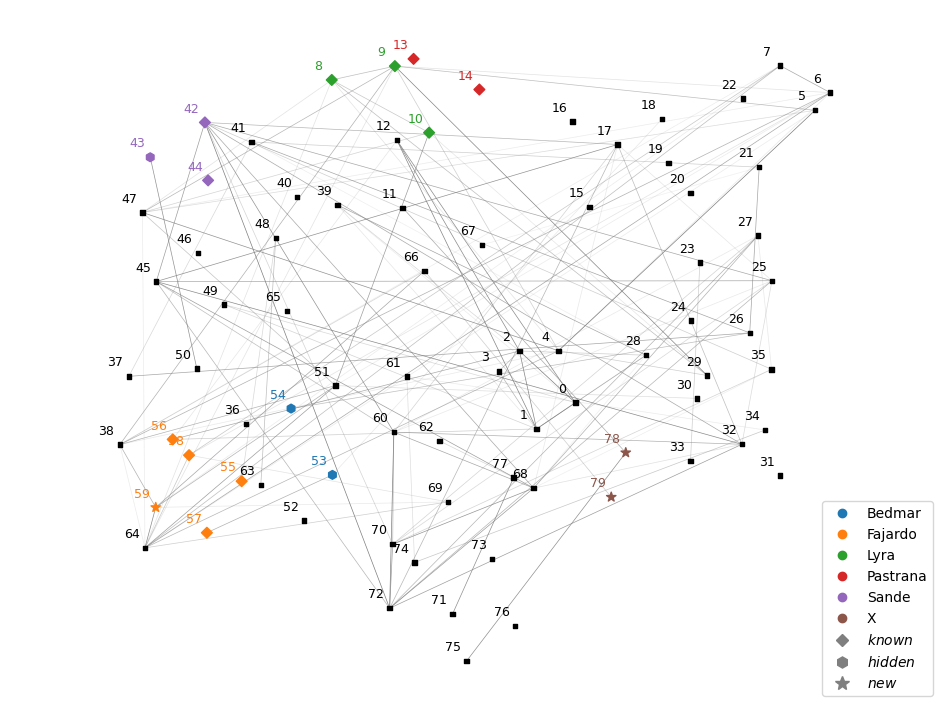

In [21]:
w_rm_ord = w_rm[inds_order]
w_it_ord = w_it[inds_order]

dists = (1-w_rm_ord) + (1-w_it_ord)
np.fill_diagonal(dists, 0)

idxs_show, = np.nonzero(np.sum(w_rm_ord+w_it_ord>0, axis=0) > 1)

for weights, sfx in zip([w_rm, w_it], ['rm', 'it']):

    plot_graph(np.arange(len(books)), dists, weights, None, idxs_show,
            markers=markers_vx,
            markersizes=markersizes_vx,
            colors=colors_vx,
            n_neighbors=5,
            min_dist=1,
            shift_dir='nw',
            # tf_geom= np.array([[0, 1/1.2], [-1.2, 0]]),
            figsize=(12, 9),
            random_state=4)

    # Empty plots to complete the legend
    for color, printer in zip(colors, printers):
        plt.plot([], [], 'o', color=color, label=printer)
    plt.plot([], [], 'D', color='tab:gray', label=r'$\mathit{known}$', markersize=6)
    plt.plot([], [], 'h', color='tab:gray', label=r'$\mathit{hidden}$', markersize=8)
    plt.plot([], [], '*', color='tab:gray', label=r'$\mathit{new}$', markersize=10)

    plt.legend()
    plt.savefig(join(save_root, f'graph1{sfx}.svg'), bbox_inches='tight', pad_inches=0, dpi=800)